In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,Binarizer,Normalizer,OneHotEncoder,LabelEncoder

In [2]:
np.random.seed(5)
a = np.random.normal(0, 2, 10000)
b = np.random.normal(5, 3, 10000)
c = np.random.normal(-5, 5, 10000)

df = pd.DataFrame({
    'A' : a,
    'B' : b,
    'C' : c
})
df

,A,B,C
0,0.882455,1.466990,-7.089363
1,-0.661740,0.571914,-3.105893
2,4.861542,7.828852,-1.039068
3,-0.504184,5.001904,-9.755722
4,0.219220,1.731128,-7.679528
...,...,...,...
9995,-0.068972,3.739968,-4.303864
9996,-2.167260,0.681434,-9.584910
9997,2.188712,9.860986,-9.986860
9998,0.595445,5.982577,-11.128039


<AxesSubplot:ylabel='Density'>

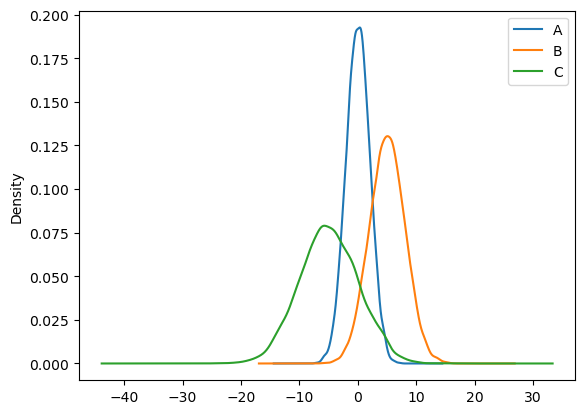

In [3]:
df.plot.kde()

In [4]:
scaler = StandardScaler()

In [5]:
scaled = scaler.fit_transform(df)

In [6]:
df = pd.DataFrame(scaled, columns=['A','B','C'])

<AxesSubplot:ylabel='Density'>

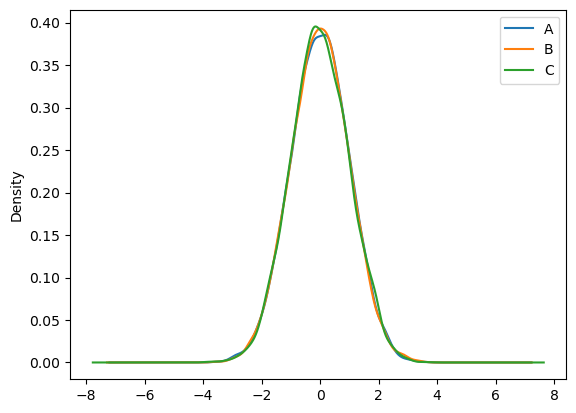

In [7]:
df.plot.kde()

In [8]:
minmax = MinMaxScaler()
mm_scaled = minmax.fit_transform(df)

<AxesSubplot:ylabel='Density'>

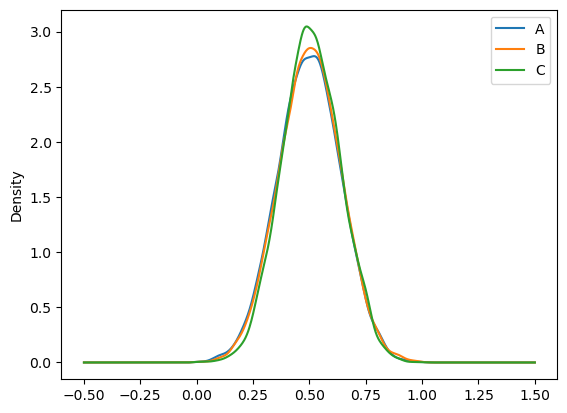

In [9]:
df = pd.DataFrame(mm_scaled,columns=['A','B','C'])
df.plot.kde()

In [10]:
rscaler = RobustScaler()

In [11]:
robust = rscaler.fit_transform(df)
df = pd.DataFrame(robust, columns=['A','B','C'])

<AxesSubplot:ylabel='Density'>

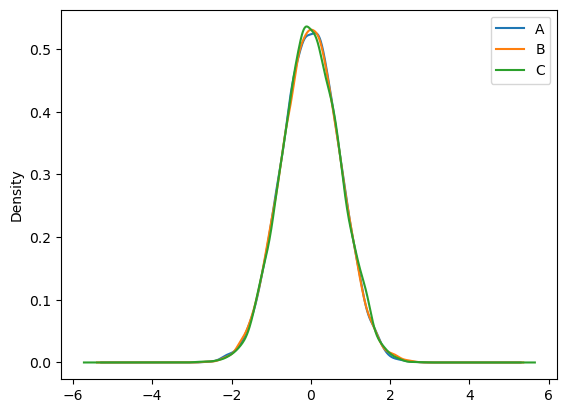

In [12]:
df.plot.kde()

In [6]:
binary = Binarizer(threshold=5)

a = np.array([[ 30, 10,  22],
              [ 20,  2,  10],
              [ 33,  5, 5]])

binary1 = binary.transform(a)
binary1

array([[1, 1, 1],
       [1, 0, 1],
       [1, 0, 0]])

In [3]:
X = [[5, 2, 3],
     [2, 4, 10],
     [6, 8, 6]]

sss = [np.sqrt(np.sum(np.power(X[i], 2))) for i in range(len(X))]

In [4]:
len(X)

3

In [20]:
np.array([X[k] / sss[k] for k in range(len(X))])

array([[0.81110711, 0.32444284, 0.48666426],
       [0.18257419, 0.36514837, 0.91287093],
       [0.51449576, 0.68599434, 0.51449576]])

In [21]:
normalizer = Normalizer()
data_tf = normalizer.fit_transform(X)

In [22]:
data_tf

array([[0.81110711, 0.32444284, 0.48666426],
       [0.18257419, 0.36514837, 0.91287093],
       [0.51449576, 0.68599434, 0.51449576]])

In [24]:
dff = pd.read_csv("/Users/shridharmankar/encoding.csv")
dff

,TEAM,YEAR
0,A,2000
1,B,2002
2,C,2003
3,D,2004
4,A,2005
5,C,2006
6,B,2007
7,A,2008
8,D,2009


In [25]:
le = LabelEncoder()
df1 = dff
df1.TEAM = le.fit_transform(df1.TEAM)
df1

,TEAM,YEAR
0,0,2000
1,1,2002
2,2,2003
3,3,2004
4,0,2005
5,2,2006
6,1,2007
7,0,2008
8,3,2009


In [26]:
enc = OneHotEncoder()
enc_df1 = pd.DataFrame(enc.fit_transform(df1[['TEAM']]).toarray())
enc_df1

,0,1,2,3
0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0
5,0.0,0.0,1.0,0.0
6,0.0,1.0,0.0,0.0
7,1.0,0.0,0.0,0.0
8,0.0,0.0,0.0,1.0


In [27]:
abc = df1.join(enc_df1)
abc

,TEAM,YEAR,0,1,2,3
0,0,2000,1.0,0.0,0.0,0.0
1,1,2002,0.0,1.0,0.0,0.0
2,2,2003,0.0,0.0,1.0,0.0
3,3,2004,0.0,0.0,0.0,1.0
4,0,2005,1.0,0.0,0.0,0.0
5,2,2006,0.0,0.0,1.0,0.0
6,1,2007,0.0,1.0,0.0,0.0
7,0,2008,1.0,0.0,0.0,0.0
8,3,2009,0.0,0.0,0.0,1.0


In [28]:
final = abc.drop(['TEAM'], axis='columns')
final

,YEAR,0,1,2,3
0,2000,1.0,0.0,0.0,0.0
1,2002,0.0,1.0,0.0,0.0
2,2003,0.0,0.0,1.0,0.0
3,2004,0.0,0.0,0.0,1.0
4,2005,1.0,0.0,0.0,0.0
5,2006,0.0,0.0,1.0,0.0
6,2007,0.0,1.0,0.0,0.0
7,2008,1.0,0.0,0.0,0.0
8,2009,0.0,0.0,0.0,1.0


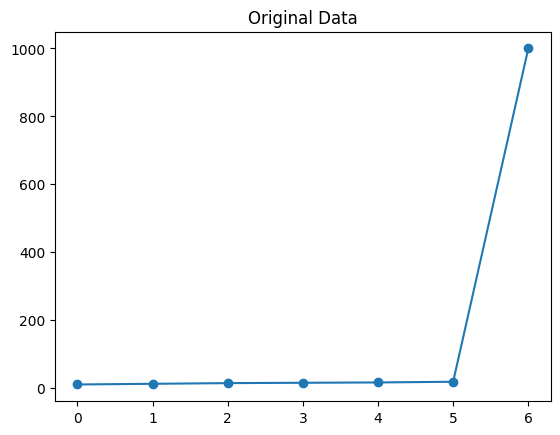

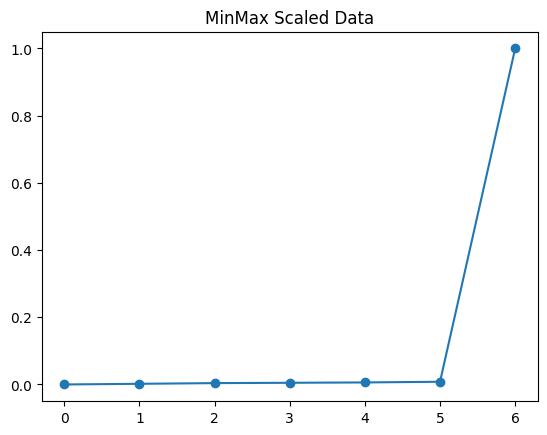

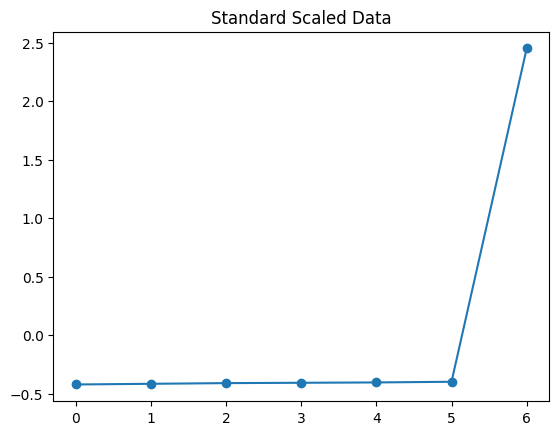

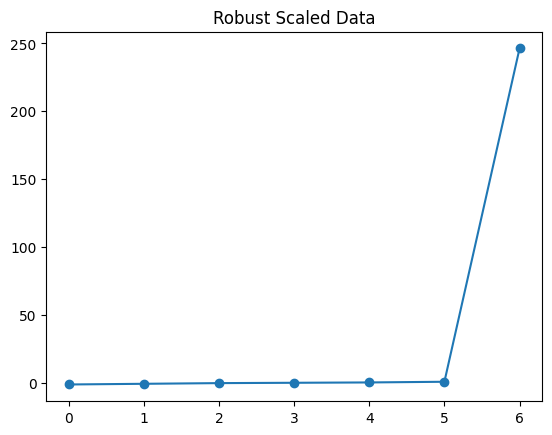

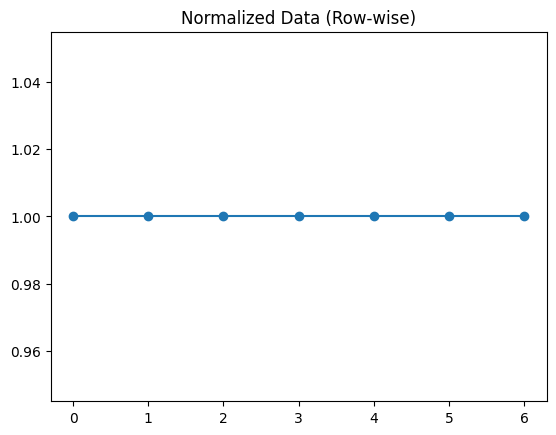

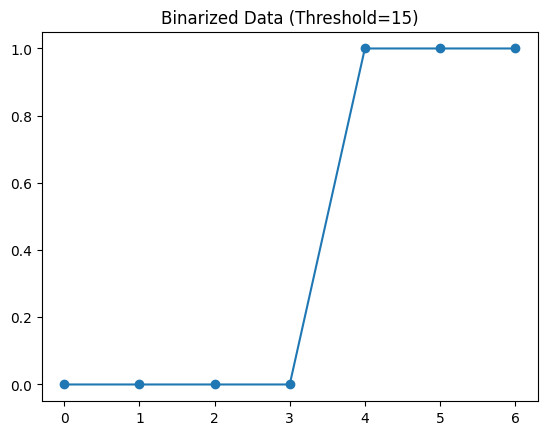

In [1]:
# Comparing 5 Scalers Side by Side (separate plots as required)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, Normalizer, Binarizer

# Sample data with outlier
X = np.array([[10], [12], [14], [15], [16], [18], [1000]])

# 1️⃣ Original Data
plt.figure()
plt.plot(X, marker='o')
plt.title("Original Data")
plt.show()

# 2️⃣ MinMaxScaler
minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X)

plt.figure()
plt.plot(X_minmax, marker='o')
plt.title("MinMax Scaled Data")
plt.show()

# 3️⃣ StandardScaler
standard = StandardScaler()
X_standard = standard.fit_transform(X)

plt.figure()
plt.plot(X_standard, marker='o')
plt.title("Standard Scaled Data")
plt.show()

# 4️⃣ RobustScaler
robust = RobustScaler()
X_robust = robust.fit_transform(X)

plt.figure()
plt.plot(X_robust, marker='o')
plt.title("Robust Scaled Data")
plt.show()

# 5️⃣ Normalizer
normalizer = Normalizer()
X_normalized = normalizer.fit_transform(X)

plt.figure()
plt.plot(X_normalized, marker='o')
plt.title("Normalized Data (Row-wise)")
plt.show()

# 6️⃣ Binarizer
binarizer = Binarizer(threshold=15)
X_binarized = binarizer.fit_transform(X)

plt.figure()
plt.plot(X_binarized, marker='o')
plt.title("Binarized Data (Threshold=15)")
plt.show()

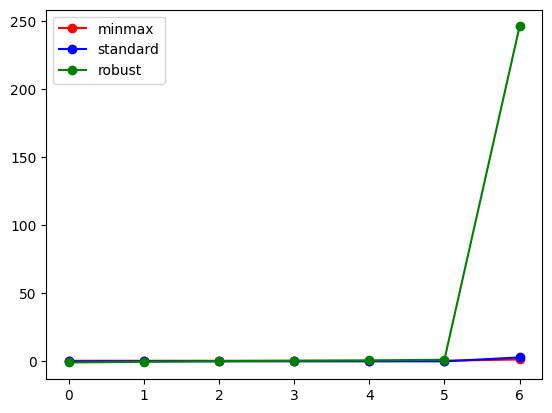

In [11]:
plt.figure()
#plt.plot(X, marker='o',color = 'blue', label = 'orginal')
plt.plot(X_minmax, marker='o', color = 'red',label = 'minmax')
plt.plot(X_standard, marker='o', color = 'blue', label = 'standard')
plt.plot(X_robust, marker='o', color = 'green', label = 'robust')
plt.legend()

In [14]:
X_robust.mean()

np.float64(35.0)

In [15]:
X_standard.mean()

np.float64(-6.344131569286608e-17)

In [19]:
X_minmax

array([[0.        ],
       [0.0020202 ],
       [0.0040404 ],
       [0.00505051],
       [0.00606061],
       [0.00808081],
       [1.        ]])

In [21]:
X_normalized

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

-----------------------------
# Practical Demo : Scaler Comparison with Outlier

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [31]:
# create dataset
X,y = make_classification(
    n_samples = 1000,
    n_features = 2,
    n_informative = 2,
    n_redundant = 0, 
    random_state = 42
)

In [32]:
X

array([[-0.99910178, -0.66386   ],
       [ 1.24668618,  1.15359685],
       [ 0.96277683,  0.85939747],
       ...,
       [-0.10126746, -1.59017563],
       [ 0.64376105, -0.78053855],
       [ 0.69852984, -1.27940455]], shape=(1000, 2))

In [33]:
#Add artificial outlier
X[:20] = X[:20] * 20

In [40]:
df = pd.DataFrame(X, columns = ['feature1', 'feature2'])
df['target'] = y

In [42]:
df.head()

,feature1,feature2,target
0,-19.982036,-13.277200,1
1,24.933724,23.071937,1
2,19.255537,17.187949,1
3,-59.148819,40.672906,1
4,22.823305,21.188973,1


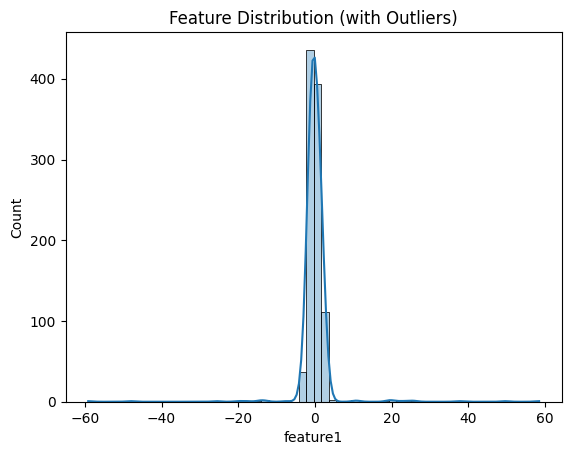

In [57]:
# Visualization........
import seaborn as sns
plt.figure()
sns.histplot(x = 'feature1', data = df, kde=True, bins=60, fill = True, alpha = 0.35)
plt.title("Feature Distribution (with Outliers)")
plt.show()

In [59]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size = 0.3, random_state=42)

In [60]:
scalers = {
    "No Scaling": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

In [61]:
results = {}

In [63]:
for name, scaler in scalers.items():
    if scaler:
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    else:
        X_train_scaled = X_train
        X_test_scaled = X_test
    
    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc

In [65]:
results.\

{'No Scaling': 0.87,
 'StandardScaler': 0.87,
 'MinMaxScaler': 0.8733333333333333,
 'RobustScaler': 0.87}

([0, 1, 2, 3],
 [Text(0, 0, 'No Scaling'),
  Text(1, 0, 'StandardScaler'),
  Text(2, 0, 'MinMaxScaler'),
  Text(3, 0, 'RobustScaler')])

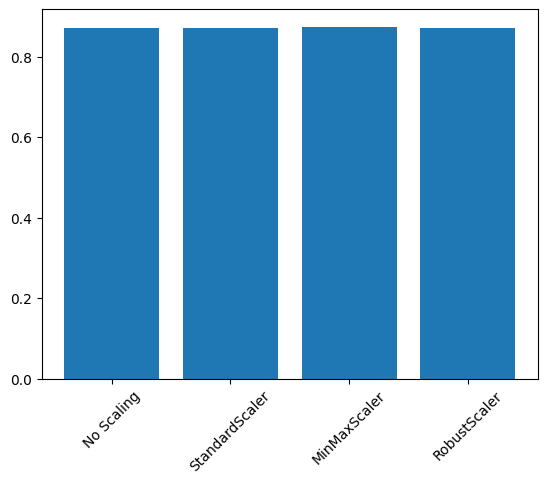

In [66]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)

{'No Scaling': 0.8933333333333333, 'StandardScaler': 0.9066666666666666, 'MinMaxScaler': 0.9, 'RobustScaler': 0.8966666666666666}


([0, 1, 2, 3],
 [Text(0, 0, 'No Scaling'),
  Text(1, 0, 'StandardScaler'),
  Text(2, 0, 'MinMaxScaler'),
  Text(3, 0, 'RobustScaler')])

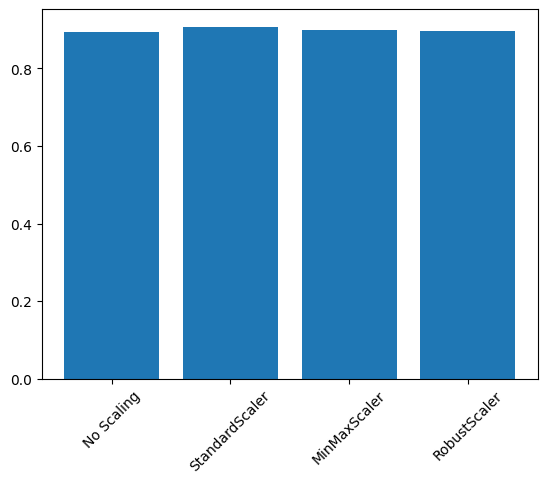

In [71]:
resutls = []
for name, scaler in scalers.items():
    if scaler:
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    else:
        X_train_scaled = X_train
        X_test_scaled = X_test
    
    model = DecisionTreeClassifier()
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
print(results)
plt.figure()
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)